# Coding Exercise 3
# Part 1a

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, HuberRegressor, Ridge, RidgeCV, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler


#Read and perform initial cleaning of the csv file
names = ["material", "density (kg/m^3)", "radius (m)", "mass (kg)", "temperature (K)", "pressure (Pa)", "height (m)", "time (s)"]
uncleaned_info = pd.read_csv("exercise3data.csv", on_bad_lines = 'skip', skiprows=4, names = names, na_values = [" ", "  ", "   "], 
                             usecols=range(8), skipinitialspace=True).dropna()
first_col = uncleaned_info.iloc[:, 0] #Skipping the first column so the names of each material don't get removed along with all N/A values
numeric_info = uncleaned_info.iloc[:, 1:].apply(pd.to_numeric, errors='coerce') #Changing all non-number entries to NaN to be removed by .dropna()
cleaned_info = numeric_info.dropna()
cleaned_info.insert(0, uncleaned_info.columns[0], first_col.loc[cleaned_info.index])

#Show the csv file, mostly cleaned
cleaned_info

#https://youtu.be/ooqXQ37XHMM?feature=shared part 2
#https://youtu.be/cWf08xuSqdU?feature=shared part 1
#https://pandas.pydata.org/docs/user_guide/io.html#csv-text-files

,material,density (kg/m^3),radius (m),mass (kg),temperature (K),pressure (Pa),height (m),time (s)
0,iron,7874.0,0.005,0.00412,306.8,100383.0,886,22.7
1,iron,7874.0,0.005,0.00412,311.3,103251.0,636,17.2
2,iron,7874.0,0.005,0.00412,309.5,101216.0,521,14.9
3,iron,7874.0,0.005,0.00412,315.7,102042.0,819,20.9
4,iron,7874.0,0.005,0.00412,301.9,99912.0,867,22.7
...,...,...,...,...,...,...,...,...
6950,magnesium,1700.0,0.025,0.11100,270.9,102417.0,768,21.5
6951,magnesium,1700.0,0.025,0.11100,300.4,96548.0,570,15.0
6952,magnesium,1700.0,0.025,0.11100,287.2,98014.0,651,17.1
6953,magnesium,1700.0,0.025,0.11100,305.5,99109.0,712,18.1


In [3]:
#Using aggregate to see the min and max values for each feature
cleaned_info.iloc[:, 1:].agg(["min", "max"])

,density (kg/m^3),radius (m),mass (kg),temperature (K),pressure (Pa),height (m),time (s)
min,1200.0,0.005,0.000628,257.3,87541.0,475,9.4
max,7874.0,0.025,0.515000,332.9,110961.0,1021,61.9


In [4]:
#Show a random "m" found in the material names
print(cleaned_info["material"].unique())

['iron' 'titanium' 'magnesium' 'm' 'silicon_carbide' 'zinc_oxide' 'silica'
 'polycarbonate']


In [5]:
#Remove the "m" and rename the data to df
df = cleaned_info[cleaned_info["material"] !="m"]
print(df["material"].unique())

['iron' 'titanium' 'magnesium' 'silicon_carbide' 'zinc_oxide' 'silica'
 'polycarbonate']


In [6]:
#Rename columns
df.rename(columns={"time (s)": "time", "pressure (Pa)": "pressure", "height (m)": "height", "density (kg/m^3)": "density", "radius (m)": "radius", 
                  "mass (kg)": "mass", "temperature (K)": "temperature"}, inplace=True)

C:\Users\chris\AppData\Local\Temp\ipykernel_6344\3937114494.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"time (s)": "time", "pressure (Pa)": "pressure", "height (m)": "height", "density (kg/m^3)": "density", "radius (m)": "radius",


# Part 1b

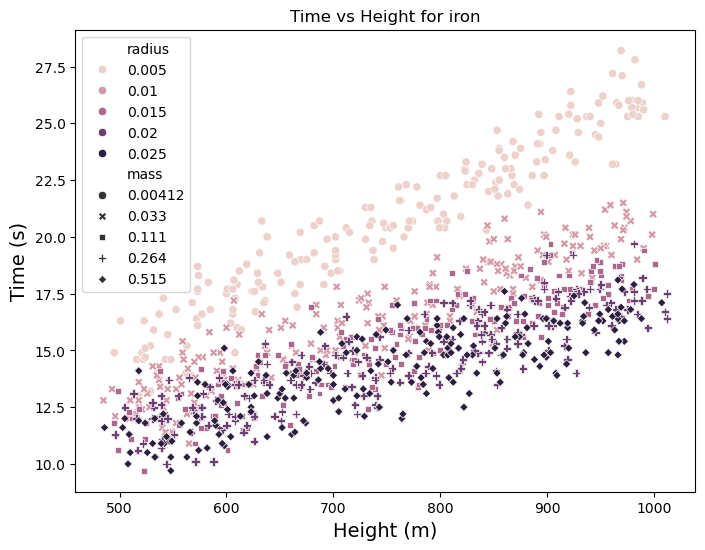

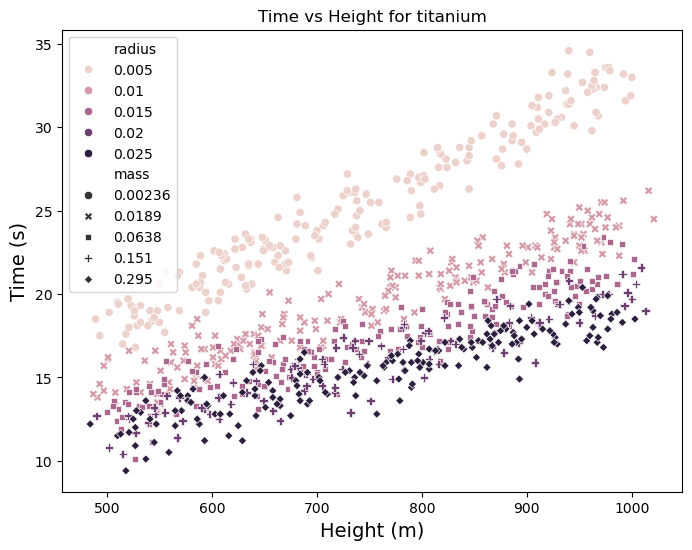

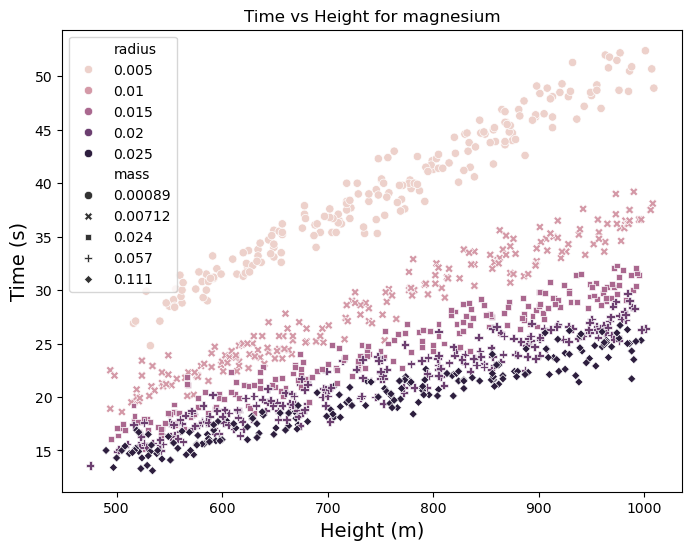

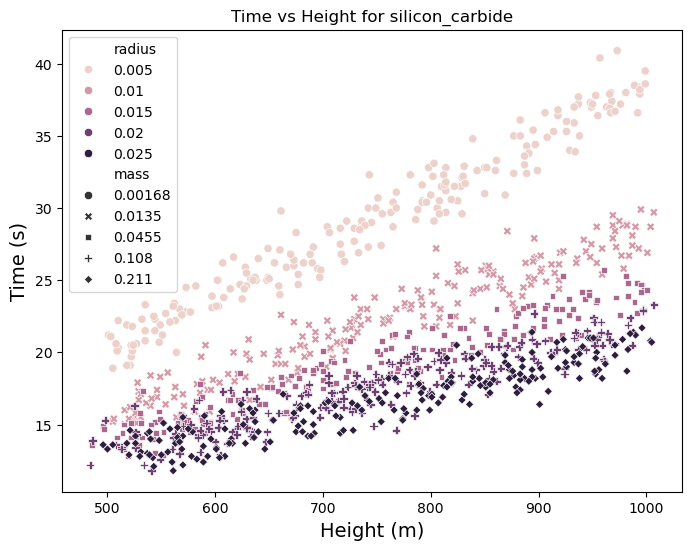

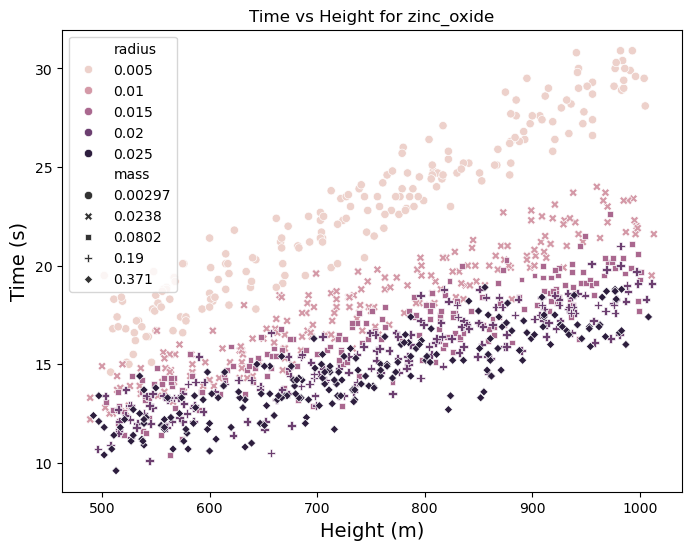

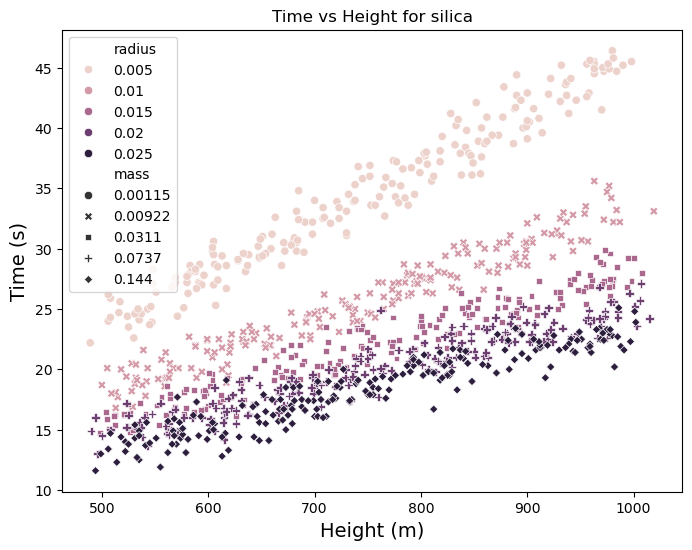

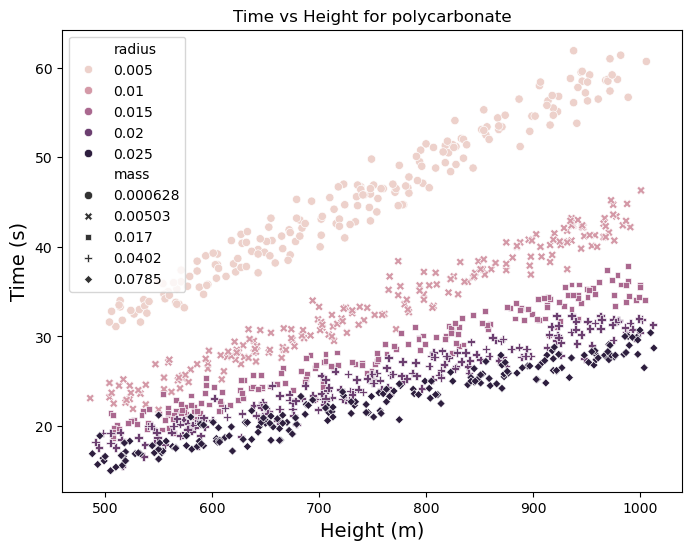

In [8]:
#List of materials over which to iterate
materials = ['iron', 'titanium', 'magnesium', 'silicon_carbide', 'zinc_oxide', 'silica', 'polycarbonate']

#Create a scatter plot for each material
for material in materials:
    
    #Filter df for the material in question and choose only numeric columns
    df_subset = df[df["material"] == material].select_dtypes(include=["number"])
    
    #Create a figure
    plt.figure(figsize = (8,6))
    
    #Plot a scatter with time on the y-axis and height on the x-axis, with colour of point indicating radius of ball dropped
    sns.scatterplot(x = "height", y = "time", data=df_subset, hue = "radius", style = "mass")
    
    #Set the appropriate axis labels
    plt.xlabel("Height (m)", fontsize=14)
    plt.ylabel("Time (s)", fontsize=14)

    #Set the title of the plot
    plt.title(f"Time vs Height for {material}")
    

# Part 2

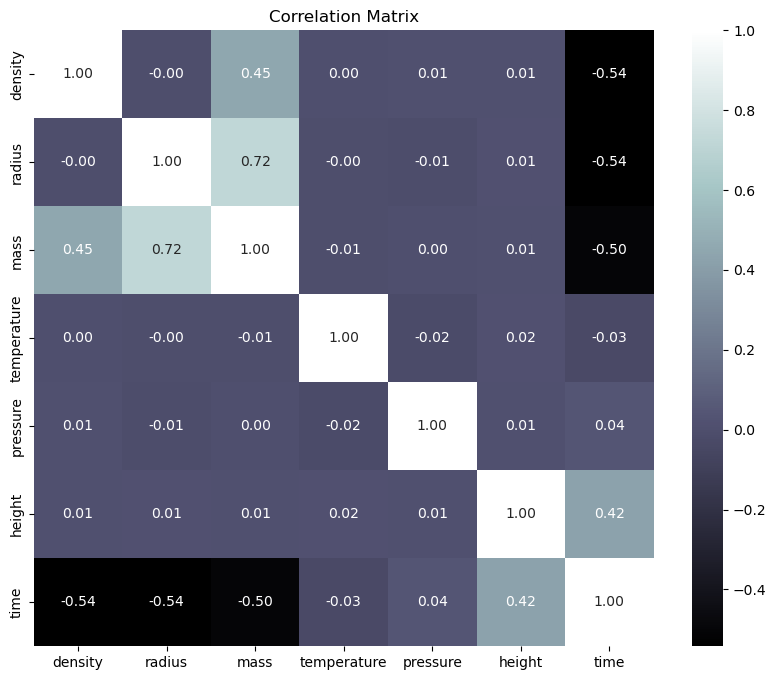

In [10]:
#Creating a correlation matrix of the data
corr_matrix = df.iloc[:, 1:].corr()
plt.figure(figsize=(10, 8))  #Adjust the size as needed
#Inserting the correlation coefficients into a heatmap in seaborn
sns.heatmap(corr_matrix, annot=True, cmap='bone', fmt='.2f')
#Plotting
plt.title('Correlation Matrix')
plt.show()


# Part 3
#### Plotting the regression lines for height against time


[0.0155513] 4.495504839641416
[0.01942675] 4.51122885874287
[0.03206004] 2.5465469532604956
[0.02326858] 3.445714935060817
[0.01743754] 4.363326127259501
[0.0271274] 3.700365022135049
[0.0356679] 4.145834390173302


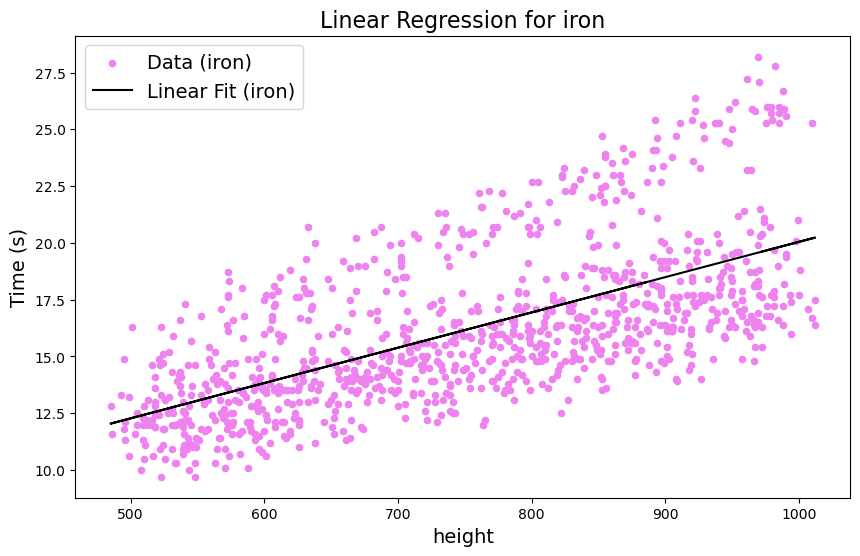

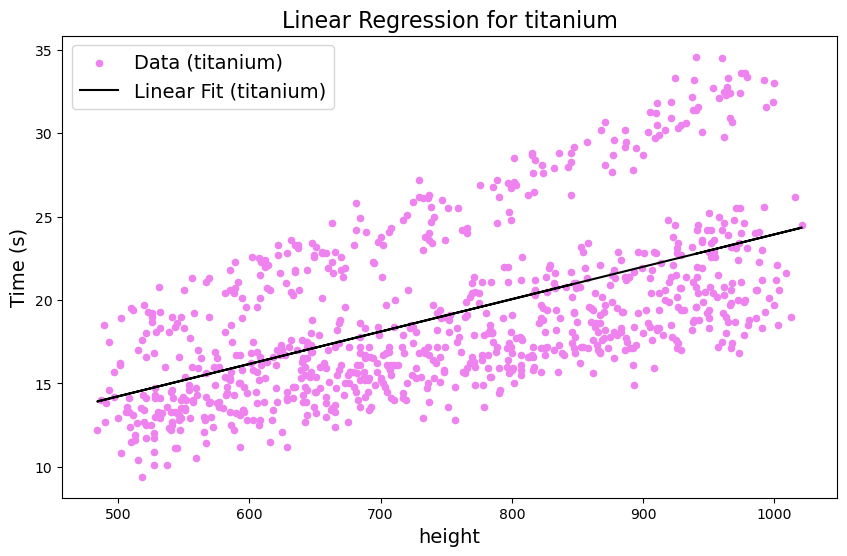

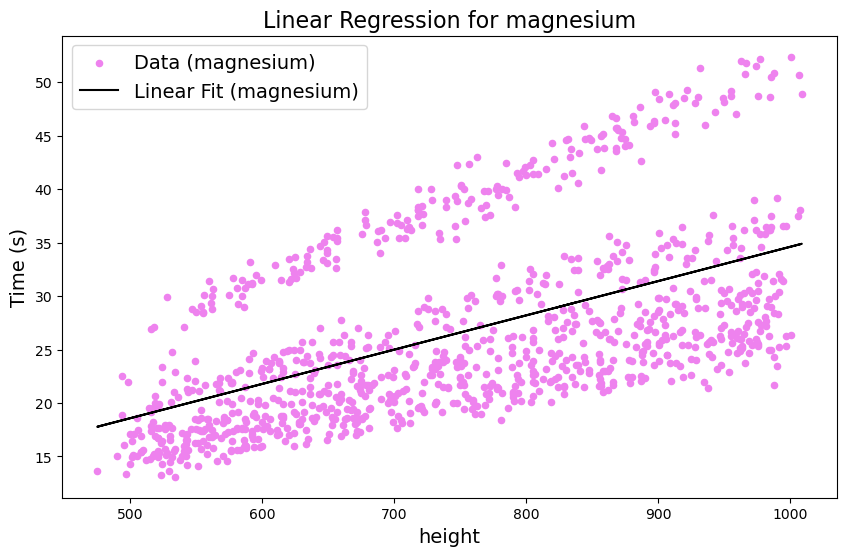

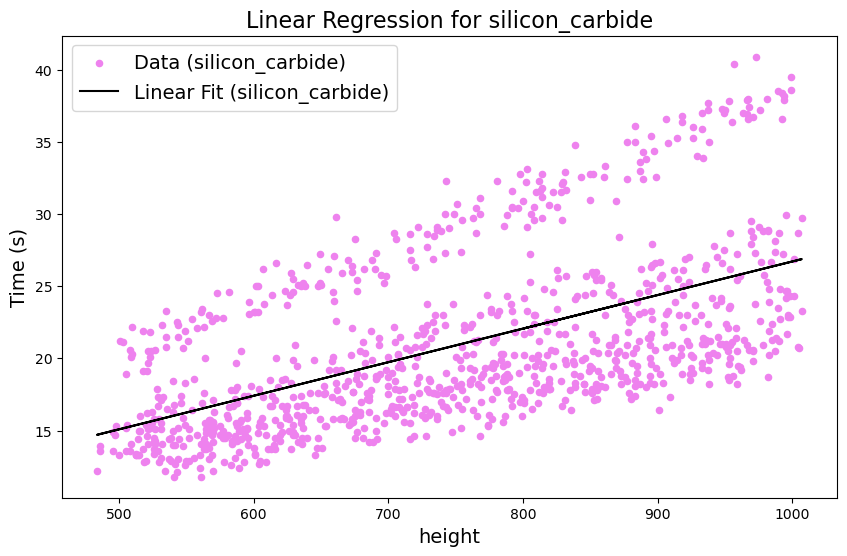

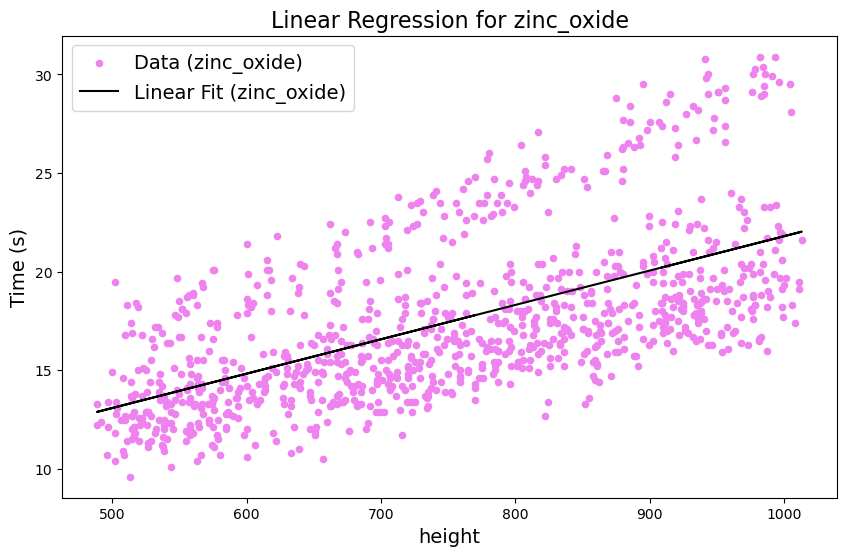

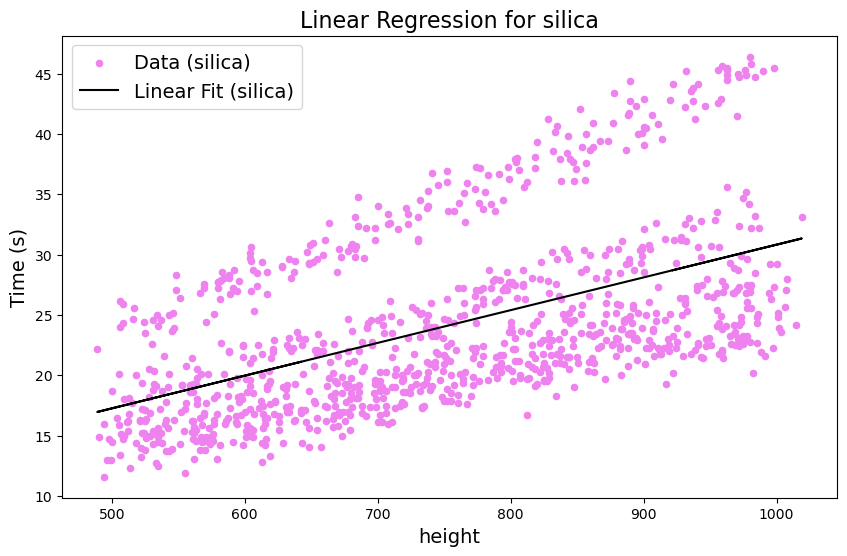

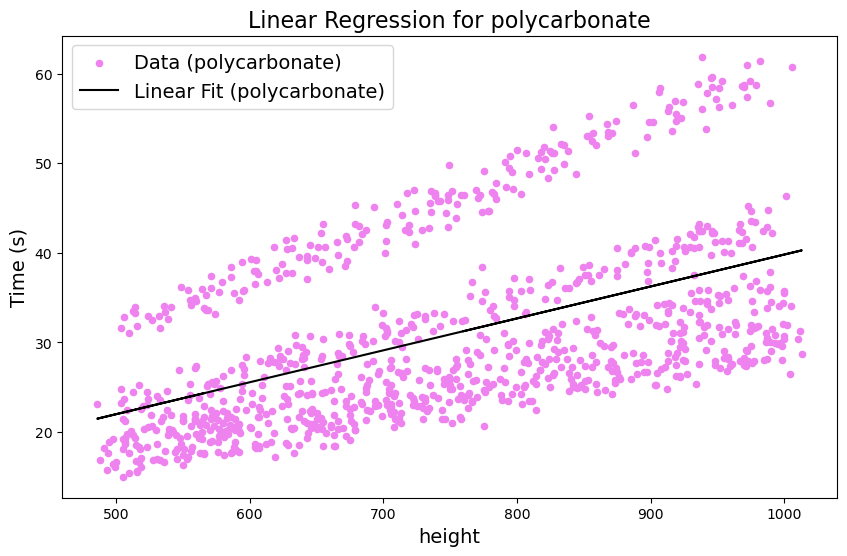

In [12]:
#List of materials over which to iterate
materials = ['iron', 'titanium', 'magnesium', 'silicon_carbide', 'zinc_oxide', 'silica', 'polycarbonate']

Ind_variable = "height"

#Fit a model of choice: input either LinearRegression(), Ridge() and Lasso()
model = LinearRegression()

for material in materials:
    
    #Filter the dataset for the selected material
    df_subset = df[df["material"] == material]
    
    #Select numeric columns for regression
    x = df_subset[Ind_variable].values.reshape(-1, 1) #Independent variable
    y = df_subset["time"].values #Dependent variable
    
    model.fit(x, y)

    #Printing model parameters
    slope, intercept = model.coef_, model.intercept_
    print(slope, intercept)
    
    #Plot the data points
    plt.figure(figsize=(10,6))
    plt.scatter(x, y, s=20, c='violet', label=f'Data ({material})')
    
    #Plot the regression line
    plt.plot(x, model.predict(x), c='k', label=f'Linear Fit ({material})')
    
    #Labels and legend
    plt.xlabel(Ind_variable, fontsize=14)
    plt.ylabel("Time (s)", fontsize=14)
    plt.legend(fontsize=14)
    plt.title(f"Linear Regression for {material}", fontsize=16)

## Finding the MSE beta coefficients and MSE loss function values for each material using three different loss functions
#### I also plot the MSE loss function values and beta coefficients in a scatter graph and bar chart respectively


Material: iron
Intercept (β0): 0.7439
density (β1): 0.000000
radius (β2): -0.000000
mass (β3): -0.000000
temperature (β4): -0.000000
pressure (β5): 0.000038
height (β6): 0.015464
Loss function = 6.954146226021663

Material: titanium
Intercept (β0): 2.8780
density (β1): 0.000000
radius (β2): -0.000000
mass (β3): -0.000000
temperature (β4): -0.021012
pressure (β5): 0.000078
height (β6): 0.019360
Loss function = 15.444002303080856

Material: magnesium
Intercept (β0): -4.7679
density (β1): 0.000000
radius (β2): -0.000000
mass (β3): -0.000000
temperature (β4): -0.027362
pressure (β5): 0.000152
height (β6): 0.032213
Loss function = 48.51620601336926

Material: silicon_carbide
Intercept (β0): 9.2679
density (β1): 0.000000
radius (β2): -0.000000
mass (β3): -0.000000
temperature (β4): -0.026930
pressure (β5): 0.000022
height (β6): 0.023157
Loss function = 22.759569591485974

Material: zinc_oxide
Intercept (β0): 1.7191
density (β1): 0.000000
radius (β2): -0.000000
mass (β3): -0.000000
temperatu

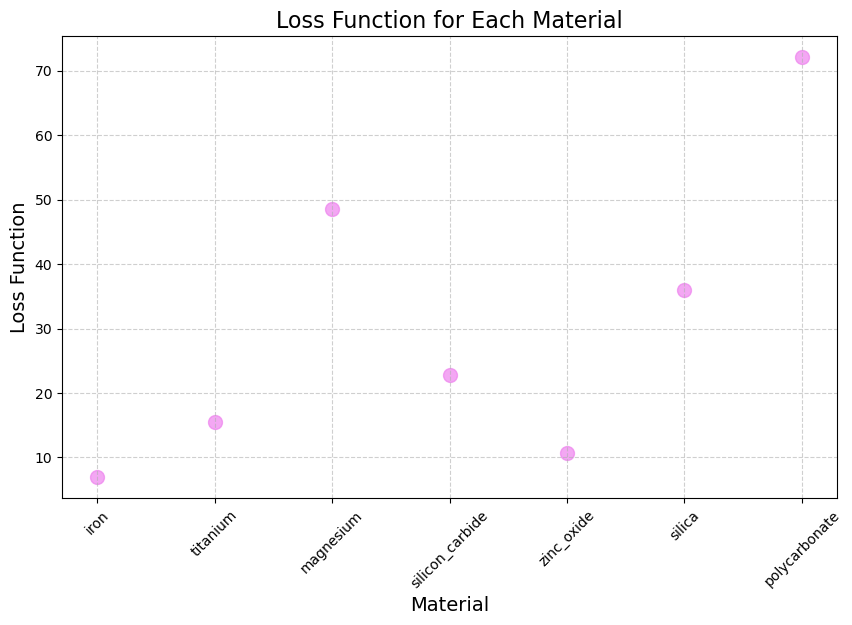

<Figure size 1200x600 with 0 Axes>

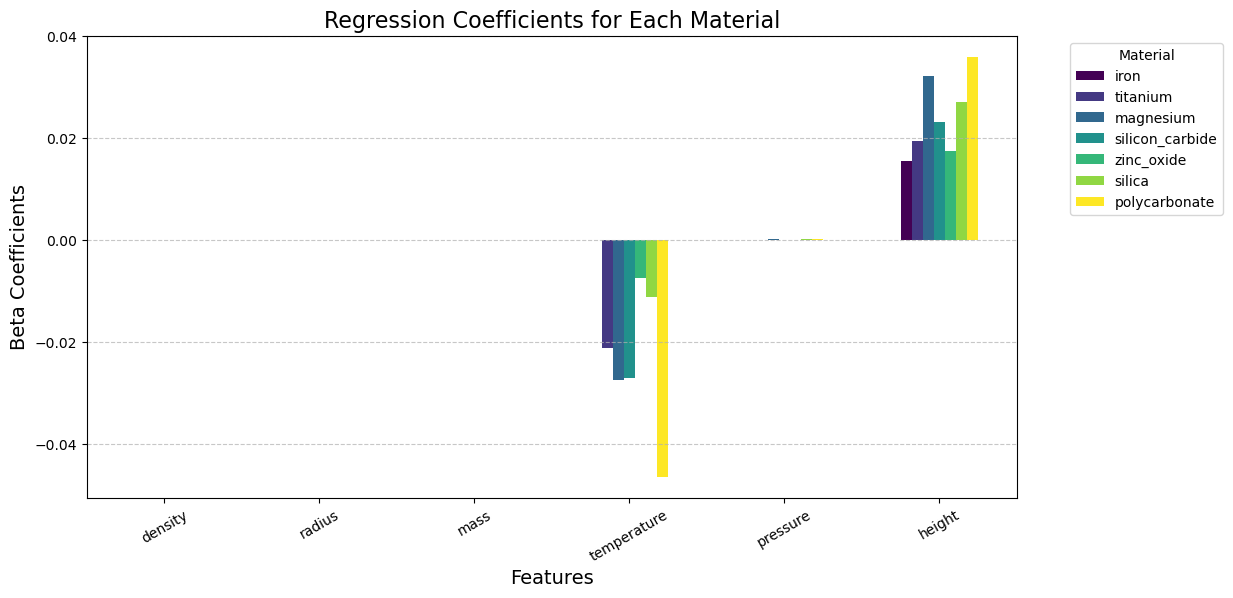

In [14]:
#List of features over which to iterate
features = ['density', 'radius', 'mass', 'temperature', 'pressure', 'height']

numbers = [1, 2, 3, 4, 5, 6]

#Initialize dictionary to store results for beta values
beta_results = {}

#Initialize list to store results for MSE values
loss_function_results = []

#Fit a model of choice: input either LinearRegression(), Ridge() and Lasso()
model = Lasso()

for material in materials:
    
    #Filter the dataset for the selected material
    df_subset = df[df["material"] == material]
    
    #Select numeric columns for regression
    x = df_subset[["density", "radius", "mass", "temperature", "pressure", "height"]].values #Independent variable
    y = df_subset["time"].values #Dependent variable
    
    model.fit(x, y)
    
    #Get model parameters
    beta_0 = model.intercept_
    beta_values = model.coef_

    #Store coefficients in dictionary
    beta_results[material] = model.coef_
    
    y_pred = model.predict(x)
        
    #Calculate loss values
    mse = mean_squared_error(y, y_pred)

    #Store results
    loss_function_results.append({"Material": material, "MSE Loss": mse})
    
    #Print results
    print(f"\nMaterial: {material}")
    print(f"Intercept (β0): {beta_0:.4f}")
    for feature, beta, num in zip(features, beta_values, numbers):
        print(f"{feature} (β{num}): {beta:.6f}")  #6 decimal places
    print("Loss function =", mse)

#=============================================================================================

#Convert MSE results to a DataFrame for plotting
mse_df = pd.DataFrame(loss_function_results)

#Scatter Plot of MSE Loss for Each Material
plt.figure(figsize=(10, 6))
plt.scatter(mse_df["Material"], mse_df["MSE Loss"], color='violet', s=100, alpha=0.7)

# Labels and Title
plt.xlabel("Material", fontsize=14)
plt.ylabel("Loss Function", fontsize=14)
plt.title("Loss Function for Each Material", fontsize=16)
plt.xticks(rotation=45)  # Rotate material names for readability
plt.grid(True, linestyle="--", alpha=0.6)

#==============================================================================================

#Convert dictionary to DataFrame for plotting
coefficients_df = pd.DataFrame.from_dict(beta_results, orient="index", columns=features)

#Plot the β coefficients as a bar chart
plt.figure(figsize=(12, 6))
coefficients_df.T.plot(kind="bar", figsize=(12, 6), colormap="viridis")

#Labels and legend
plt.xlabel("Features", fontsize=14)
plt.ylabel("Beta Coefficients", fontsize=14)
plt.title("Regression Coefficients for Each Material", fontsize=16)
plt.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')

#Show plot
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


## Finding the beta coefficients for the MAE loss function values
#### Here I use the HuberRegressor() function to find alternative beta coefficients with less tolerance for outliers. I also plot the MAE loss function values and beta values for each material in scatter graph and bar chart respectively


Material: iron
Intercept (β0): 0.0000
density (β1): 0.000285
radius (β2): -0.000001
mass (β3): -0.000017
temperature (β4): 0.000008
pressure (β5): 0.000030
height (β6): 0.013699
MAE loss function = 1.97093752164499

Material: titanium
Intercept (β0): 0.0000
density (β1): 0.001490
radius (β2): -0.000248
mass (β3): -0.003328
temperature (β4): -0.030782
pressure (β5): 0.000072
height (β6): 0.017475
MAE loss function = 3.0208333668051854

Material: magnesium
Intercept (β0): -0.0000
density (β1): -0.001722
radius (β2): -0.000366
mass (β3): -0.001926
temperature (β4): -0.036918
pressure (β5): 0.000165
height (β6): 0.028628
MAE loss function = 5.215413203714432

Material: silicon_carbide
Intercept (β0): 0.0000
density (β1): 0.002754
radius (β2): -0.057678
mass (β3): -0.576305
temperature (β4): -0.030825
pressure (β5): 0.000049
height (β6): 0.020310
MAE loss function = 3.596872241098499

Material: zinc_oxide
Intercept (β0): 0.0000
density (β1): 0.000617
radius (β2): -0.000001
mass (β3): -0.00

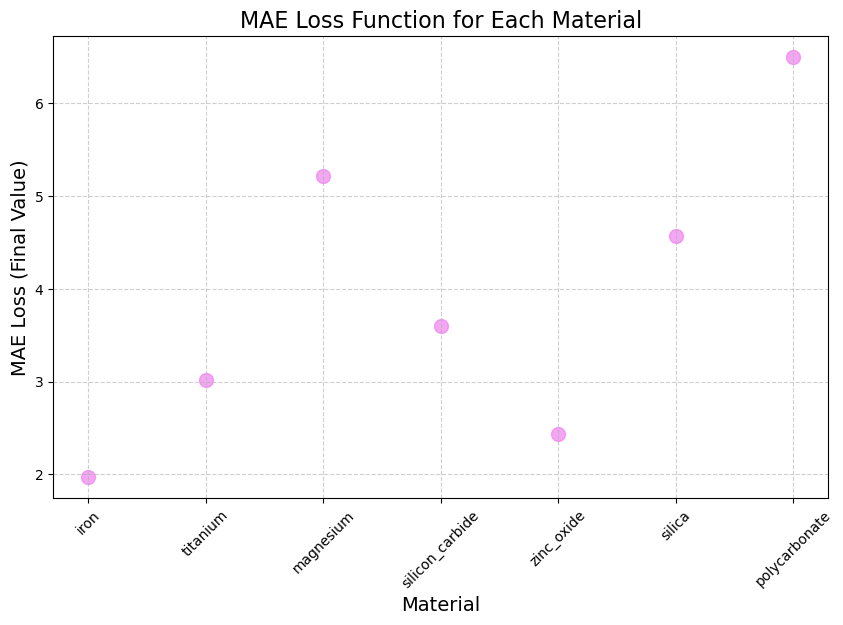

<Figure size 1200x600 with 0 Axes>

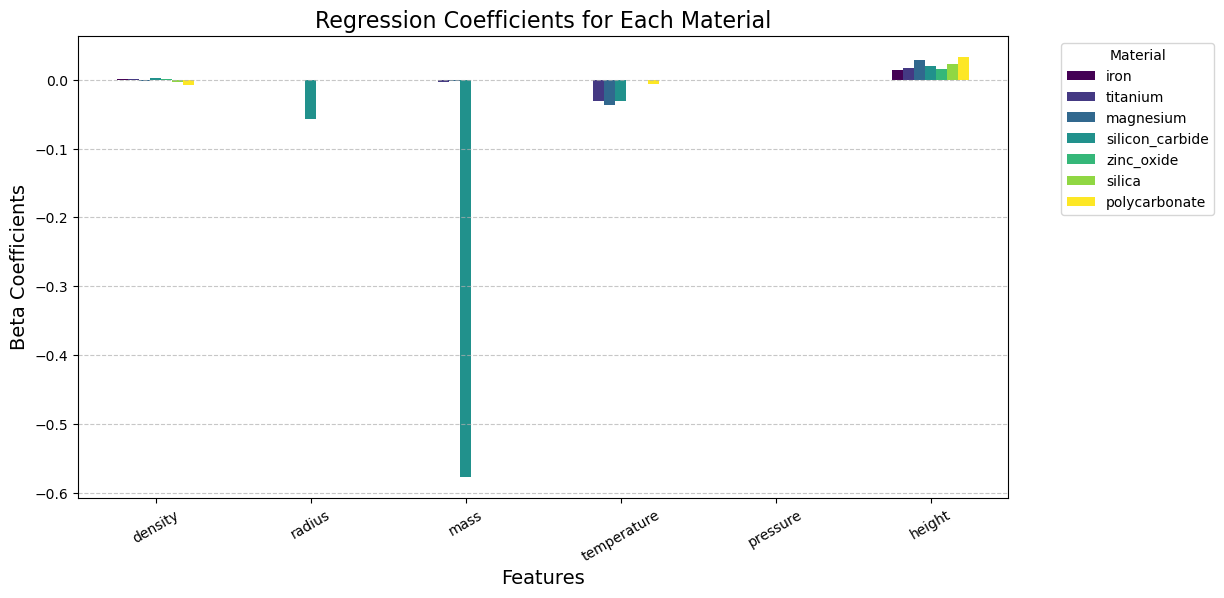

In [16]:
#Initialize dictionary to store beta value results
second_betas_results = {}

#Initialize dictionary to store results for MSE values
MAE_results = []

for material in materials:
    
    #Filter the dataset for the selected material
    df_subset = df[df["material"] == material]
    
    #Select numeric columns for regression
    x = df_subset[["density", "radius", "mass", "temperature", "pressure", "height"]].values #Independent variable
    y = df_subset["time"].values #Dependent variable
    
    #Fit MAE loss function model
    model = HuberRegressor()
    model.fit(x, y)
    
    #Get model parameters
    beta_0 = model.intercept_
    beta_values = model.coef_

    #Store coefficients in dictionary
    second_betas_results[material] = model.coef_

    #Make predictions
    y_pred = model.predict(x)
    
    #Calculate loss values
    mae = mean_absolute_error(y, y_pred)

    #Store results
    MAE_results.append({"Material": material, "MAE Loss": mae})
    
    #Print results
    print(f"\nMaterial: {material}")
    print(f"Intercept (β0): {beta_0:.4f}")
    for feature, beta, num in zip(features, beta_values, numbers):
        print(f"{feature} (β{num}): {beta:.6f}")  #6 decimal places
    print("MAE loss function =", mae)


#=============================================================================================
#Convert MAE results to a DataFrame for plotting
mae_df = pd.DataFrame(MAE_results)

#Scatter Plot of MAE Loss for Each Material
plt.figure(figsize=(10, 6))
plt.scatter(mae_df["Material"], mae_df["MAE Loss"], color='violet', s=100, alpha=0.7)

# Labels and Title
plt.xlabel("Material", fontsize=14)
plt.ylabel("MAE Loss (Final Value)", fontsize=14)
plt.title("MAE Loss Function for Each Material", fontsize=16)
plt.xticks(rotation=45)  # Rotate material names for readability
plt.grid(True, linestyle="--", alpha=0.6)

#===========================================================================================
#Convert dictionary to DataFrame for plotting beta values
coefficients_df = pd.DataFrame.from_dict(second_betas_results, orient="index", columns=features)

#Plot the β coefficients as a bar chart
plt.figure(figsize=(12, 6))
coefficients_df.T.plot(kind="bar", figsize=(12, 6), colormap="viridis")

#Labels and legend
plt.xlabel("Features", fontsize=14)
plt.ylabel("Beta Coefficients", fontsize=14)
plt.title("Regression Coefficients for Each Material", fontsize=16)
plt.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left')

#Show plot
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


## Part 3c: Gradient descent
#### Here I will use and compare the standard method of batch gradient descent against the stochastic and mini-batch methods

### Standard (batch) gradient descent

Initial Loss: 228.987246114649
Final Loss: 2.24564591079387, Improvement: 99.02%


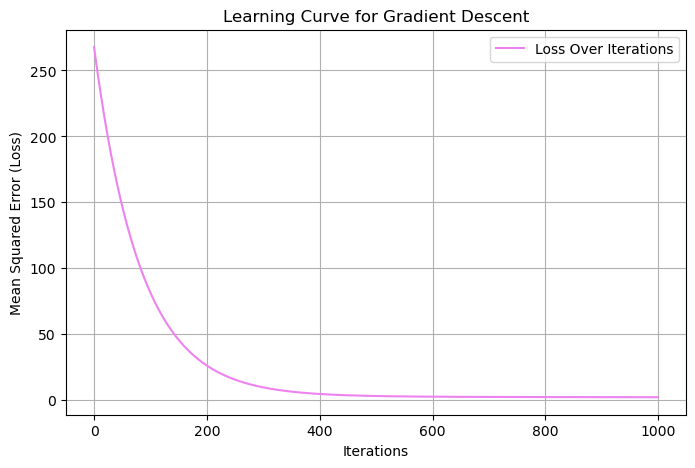

Final theta values (BGD): [[ 1.61552019e+01]
 [ 4.29143093e-03]
 [-2.27287799e+00]
 [ 2.95158652e-01]
 [-1.37727641e-01]
 [ 1.11142102e-01]
 [ 2.27300208e+00]]


In [19]:
#Only perform the gradient descent for the iron data
filtered_df = df[df["material"] == "iron"]

#Separate the features (X) and target (y)
yp_wo = filtered_df["time"].values.reshape(-1, 1)  #Extract the target variable "time"
X_filtered = filtered_df.drop(columns=["material", "time"]).values  #Exclude non-numeric columns


#Gradient Descent Setup
eta = 0.003 #Learning rate
n_iterations = 1000 #Number of iterations


#Scale the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

#Add a column of ones to X_scaled for the bias term and relabel the variable
X = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

#Get the number of instances and features, m and n
m, n = X.shape 

#Initialize theta parameters randomly
np.random.seed(10)
theta_ne = np.random.randn(n, 1)

#Calculate the initial loss (Mean Squared Error)
loss_ne = np.mean((X.dot(theta_ne) - yp_wo) ** 2)
print("Initial Loss:", loss_ne)

theta_path_bgd = [] #Store theta at each iteration
loss_history = []  #Store loss at each iteration
theta = np.random.randn(n, 1)  #Initialize based on number of features

#Standard batch Gradient Descent Loop
for iteration in range(n_iterations):
    gradients = (2 / m) * X.T.dot(X.dot(theta) - yp_wo)
    theta -= eta * gradients
    theta_path_bgd.append(theta.copy())
    
    #Compute and store loss for this iteration
    loss = np.mean((X.dot(theta) - yp_wo) ** 2)
    loss_history.append(loss)

theta_path_bgd = np.array(theta_path_bgd)  #Save the thetas

theta_bgd = theta  #Final theta values

#Compute loss after GD
loss_bgd = np.mean((X.dot(theta_bgd) - yp_wo) ** 2)

#Percent improvement in loss
percent_improvement = (loss_ne - loss_bgd) / loss_ne * 100
print(f"Final Loss: {loss_bgd}, Improvement: {percent_improvement:.2f}%")

#Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(n_iterations), loss_history, label="Loss Over Iterations", color="violet")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error (Loss)")
plt.title("Learning Curve for Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

#Print final thetas
print("Final theta values (BGD):", theta_bgd)

### Stochastic gradient descent

Final Loss: 0.8537648744059715, Improvement: 91.95%


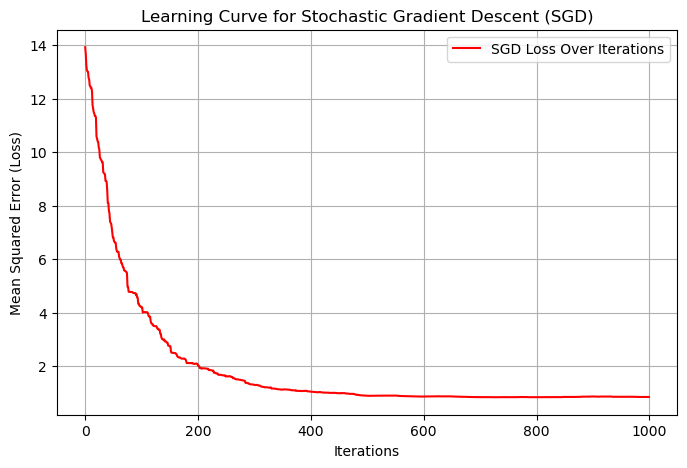

Final theta values (SGD): [[ 0.09711919]
 [ 2.04354525]
 [ 2.91977932]
 [-0.01841306]
 [ 0.03078266]
 [ 0.08516789]
 [-0.01137566]]


In [21]:
np.random.seed(10)

m = 100  #Number of samples
n = 6    #Number of features
X = np.random.randn(m, n)  #Shape: (m, n)
yp_wo = 2 * X[:, 0].reshape(-1, 1) + 3 * X[:, 1].reshape(-1, 1) + np.random.randn(m, 1)  #Target variable

#Add a column of ones to X for the bias term
X_b = np.c_[np.ones((m, 1)), X]  #Shape: (m, n+1)

#Initialize theta with the correct shape
theta = np.random.randn(n + 1, 1)  #Shape: (n+1, 1)

eta = 0.003  #Learning rate
n_iterations = 1000  #Number of iterations

theta_path_sgd = []
loss_history_sgd = []

#Stochastic Gradient Descent (SGD)
for epoch in range(n_iterations):
    random_index = np.random.randint(m)  #Pick a random training example
    
    x_one = X_b[random_index:random_index+1]
    y_one = yp_wo[random_index:random_index+1]
    
    gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)  #Compute gradients
    theta -= eta * gradients  #Update theta
    
    theta_path_sgd.append(theta.copy())  #Store theta history

    #Compute and store loss for this iteration
    loss = np.mean((X_b.dot(theta) - yp_wo) ** 2)
    loss_history_sgd.append(loss)

theta_path_sgd = np.array(theta_path_sgd)  #Convert list to array
theta_sgd = theta  #Final theta values

#Compute loss after SGD
loss_sgd = np.mean((X_b.dot(theta_sgd) - yp_wo) ** 2)

#Percent improvement in loss
loss_ne = np.mean((X_b.dot(np.zeros((n + 1, 1))) - yp_wo) ** 2)  #Loss for theta = 0
percent_improvement = (loss_ne - loss_sgd) / loss_ne * 100
print(f"Final Loss: {loss_sgd}, Improvement: {percent_improvement:.2f}%")

#Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(n_iterations), loss_history_sgd, label="SGD Loss Over Iterations", color="r")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error (Loss)")
plt.title("Learning Curve for Stochastic Gradient Descent (SGD)")
plt.legend()
plt.grid(True)
plt.show()

#Print final thetas
print("Final theta values (SGD):", theta_sgd)

### Mini-batch gradient descent

[[ 2.03068034e+00]
 [ 2.92522271e+00]
 [-1.25219185e-03]
 [-2.17535814e-02]
 [ 4.71940862e-02]
 [-1.15622830e-01]]
Final Loss: 0.8471891504736191, Improvement: 92.01%


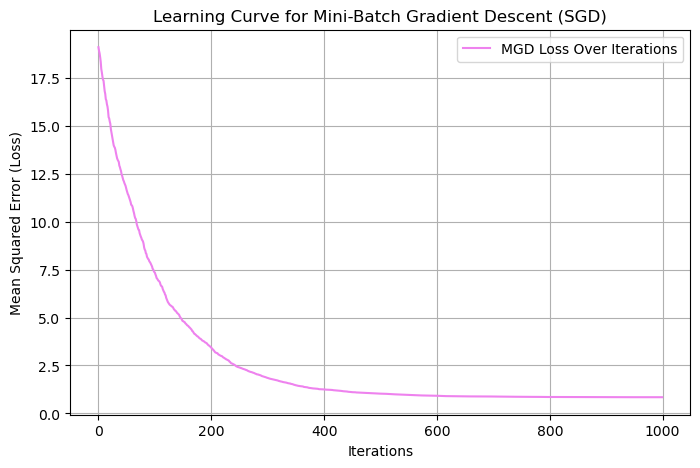

In [23]:
theta = np.random.randn(n,1) 

eta = 0.003

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10 #size of the mini batch

loss_history_mgd = []  # Store loss at each iteration

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m) #shuffle array 
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size] #select the first set from the shuffled array; equivalent to selecting a random subset
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    
    theta = theta - eta * gradients
    
    theta_path_mgd.append(theta)

    # Compute and store loss for this iteration
    loss = np.mean((X.dot(theta) - yp_wo) ** 2)
    loss_history_mgd.append(loss)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta 

print(theta_mgd)

# Compute loss after SGD
loss_mgd = np.mean((X.dot(theta_mgd) - yp_wo) ** 2)

# Percent improvement in loss
percent_improvement = (loss_ne - loss_mgd) / loss_ne * 100
print(f"Final Loss: {loss_mgd}, Improvement: {percent_improvement:.2f}%")

# Plot the Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(range(n_iterations), loss_history_mgd, label="MGD Loss Over Iterations", color="violet")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error (Loss)")
plt.title("Learning Curve for Mini-Batch Gradient Descent (SGD)")
plt.legend()
plt.grid(True)
plt.show()

# Part 4

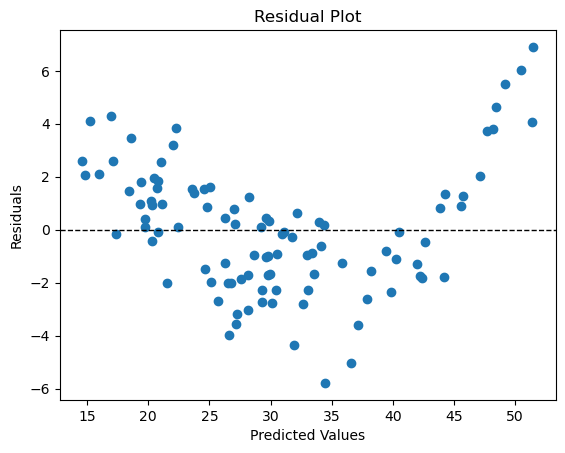

Mean of residuals: 0.026525640203799234
Standard deviation of residuals: 2.4027591812212257


In [25]:
X = df_subset[["density", "radius", "mass", "temperature", "pressure", "height"]].values #Independent variable
y = df_subset["time"].values #Dependent variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = (y_test - y_pred)

#Plotting
plt.scatter(y_pred, residuals)
#Adding 
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='y = 0')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

mean_residual = np.mean(residuals)
std_residual = np.std(residuals)
print(f"Mean of residuals: {mean_residual}")
print(f"Standard deviation of residuals: {std_residual}")

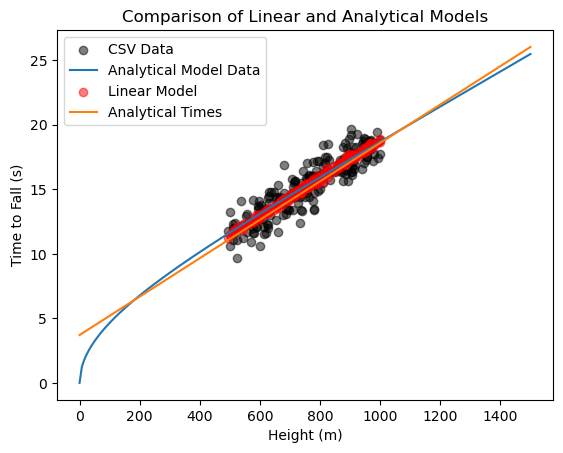

In [106]:
#Comparing with an analytical model

#Constants
drag_coefficient = 0.47 #for a sphere
air_molar_mass = 0.02896 #kg/mol
g = 9.81 #acceleration due to gravity m/s^2
R = 8.31446261815324 #molar gas constant in J/K

def analytical_model(df, chosen_radius):
    """
    radius_choice = The radius of ball for which the model will compare real data and the analytical model's data (m).
    """
    #
    specific_radius_data = df[df["radius"] == radius_choice]
    
    #Get required columns
    pressure = specific_radius_data["pressure"].mean() #atmospheric pressure
    temperature = specific_radius_data["temperature"].mean() #atmospheric temperature
    mass = specific_radius_data["mass"].iloc[0] #Ball mass
    radius = specific_radius_data["radius"].iloc[0] #Ball radius
    
    heights = np.linspace(0, 1500, len(specific_radius_data))
    
    #Setting up time analysis equations
    air_density = (pressure*air_molar_mass)/(R*temperature)
    cross_sect_area = np.pi*radius**2
    k = drag_coefficient*air_density*cross_sect_area/2

    time_model = np.sqrt(mass/(k*g))*np.arccosh(np.exp((heights*k)/mass))

    #Extract data from the original dataframe with specified radii
    df_times = specific_radius_data["time"]
    df_heights = specific_radius_data["height"]

    regression_data = specific_radius_data.drop(columns = ["material"])
    regression_data_array = regression_data.to_numpy()

    variables = regression_data_array[:,:-1]
    regression_t = regression_data_array[:,-1]
    regression_h = regression_data["height"].to_numpy().reshape(-1,1)
    
    model = LinearRegression()
    model.fit(variables, regression_t)
    predicted_regression_t = model.predict(variables)
    
    analysis_model = LinearRegression()
    analysis_model.fit(heights.reshape(-1,1), time_model)
    analytical_time_model = analysis_model.predict(heights.reshape(-1,1))
    
    
    
    return time_model, heights, df_heights, df_times, predicted_regression_t, regression_h, analytical_time_model

#Choose from 0.005, 0.010, 0.015, 0.020, 0.025
radius_choice = 0.015
iron_data = df[df["material"] == "iron"]

time_model, heights, df_heights, df_times, predicted_regression_t, regression_h, analytical_time_model  = analytical_model(iron_data, radius_choice, )

plt.scatter(df_heights, df_times, color="k", alpha=0.5, label='CSV Data')
plt.plot(heights, time_model, label='Analytical Model Data')
plt.scatter(regression_h, predicted_regression_t, color="red", alpha=0.5, label='Linear Model')
plt.plot(heights, analytical_time_model, label='Analytical Times')
plt.xlabel('Height (m)')
plt.ylabel('Time to Fall (s)')
plt.title('Comparison of Linear and Analytical Models')
plt.legend()
plt.show()